In [1]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn

**1. Set Up**

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
from matplotlib import rcParams
# configurations

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

plt.rcParams.update({"figure.figsize": (10, 8),
                    "axes.titlesize": 15,
                     "axes.labelsize": 15,
                     "xtick.labelsize": 8,
                     "ytick.labelsize": 8})

RANDOM_STATE = 42
CSV_PATH = "/content/sample_data/Mall_Customers.csv"

**2. Load Data**

In [4]:
df = pd.read_csv(CSV_PATH)

In [5]:
print("First five rows:\n")
df.head()

First five rows:



,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
print("Shape:", df.shape)

Shape: (200, 5)


**3. Exploratory Data Anaysis**

In [7]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [8]:
# Basic Data Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.000,100.500,57.879,1.000,50.750,100.500,150.250,200.000
Age,200.000,38.850,13.969,18.000,28.750,36.000,49.000,70.000
Annual Income (k$),200.000,60.560,26.265,15.000,41.500,61.500,78.000,137.000
Spending Score (1-100),200.000,50.200,25.824,1.000,34.750,50.000,73.000,99.000


In [10]:
# save CustomerID to a list for later use
customer_id = df["CustomerID"]

In [11]:
customer_id.head()

,CustomerID
0,1
1,2
2,3
3,4
4,5


In [12]:
# drop CustomerID column as it is not useful for modelling
df = df.drop(columns=["CustomerID"])

In [13]:
df.isnull().sum()

,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [14]:
df_duplicated = df.duplicated()
print("No of Duplicates:", df_duplicated.sum())
print("Duplicated Row:", df[df_duplicated])

No of Duplicates: 0
Duplicated Row: Empty DataFrame
Columns: [Gender, Age, Annual Income (k$), Spending Score (1-100)]
Index: []


In [15]:
# Check for Missing Encoded Values

for col in df.columns:
  print(df[col].value_counts().head(20))

Gender
Female    112
Male       88
Name: count, dtype: int64
Age
32    11
35     9
31     8
19     8
30     7
49     7
23     6
40     6
36     6
27     6
47     6
38     6
50     5
20     5
21     5
29     5
48     5
34     5
67     4
54     4
Name: count, dtype: int64
Annual Income (k$)
54    12
78    12
60     6
48     6
63     6
71     6
62     6
87     6
40     4
43     4
46     4
20     4
39     4
19     4
33     4
28     4
77     4
67     4
73     4
88     4
Name: count, dtype: int64
Spending Score (1-100)
42    8
55    7
73    6
46    6
48    5
52    5
50    5
59    5
75    5
35    5
41    4
56    4
5     4
47    4
14    4
40    4
60    3
13    3
15    3
77    3
Name: count, dtype: int64


**Data Visualization**

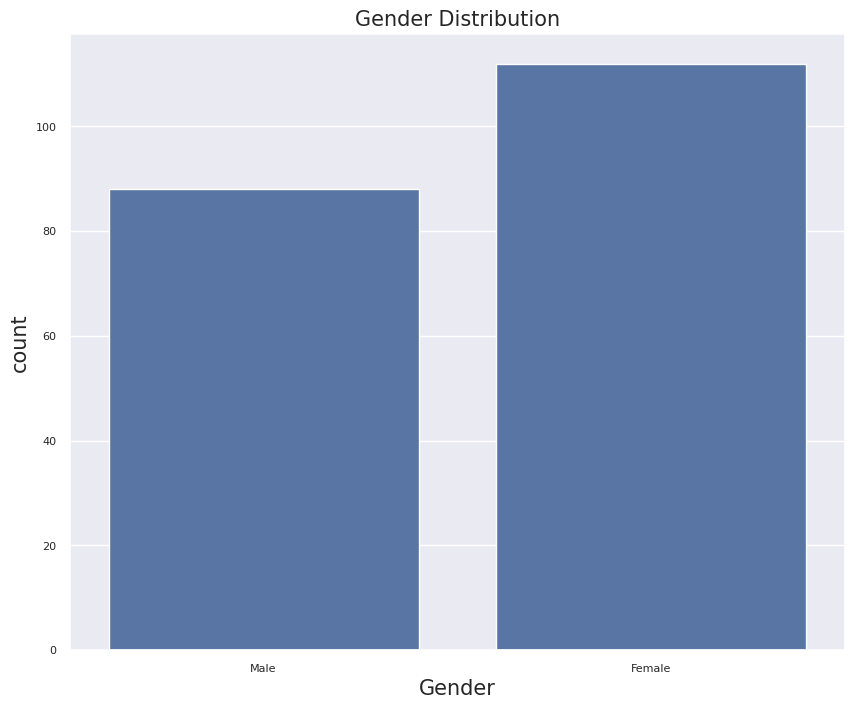

In [16]:

sns.countplot(data=df, x="Gender")
plt.title("Gender Distribution")
plt.show()

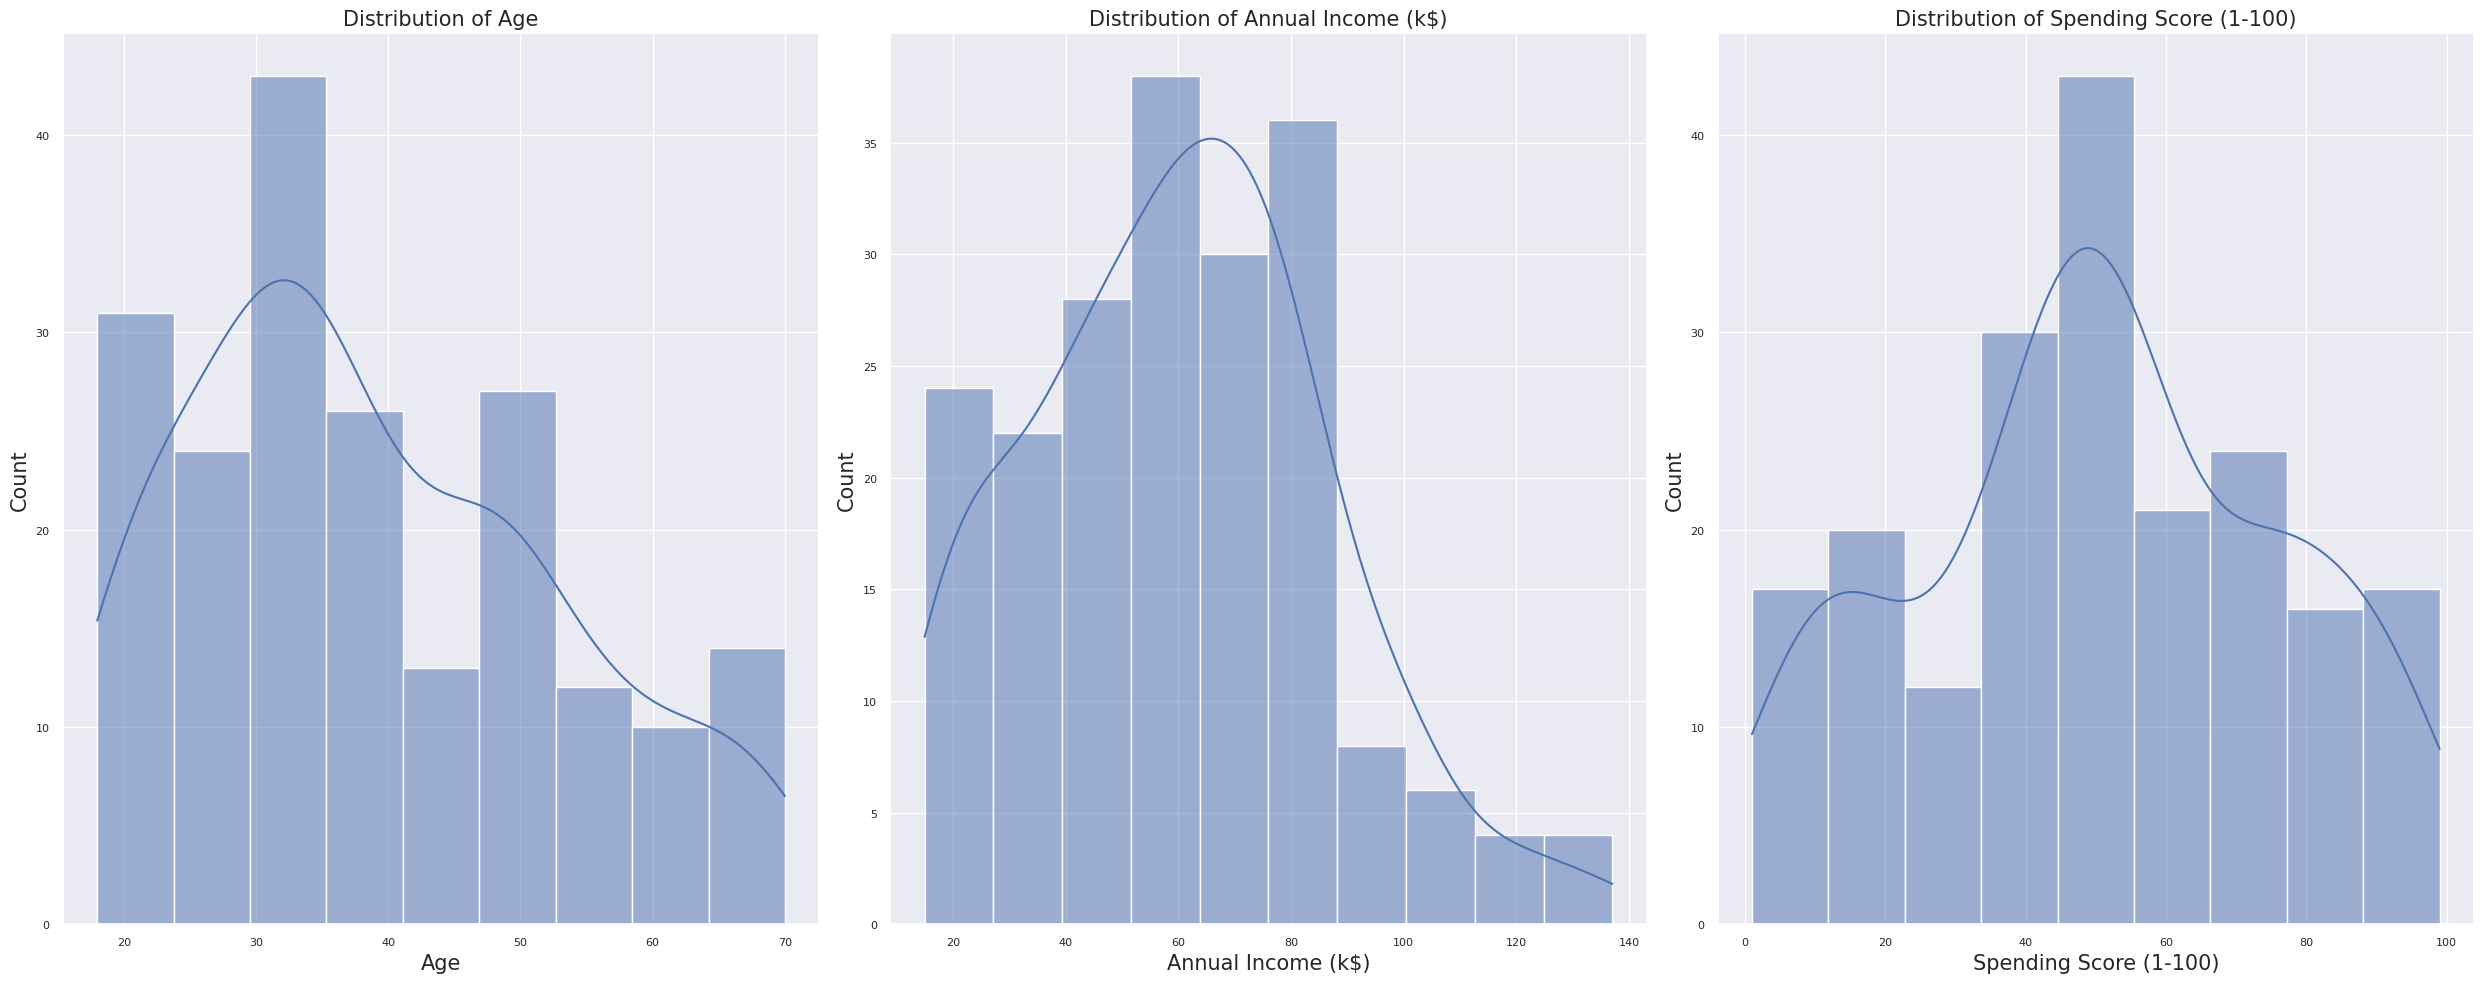

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(25, 10))
axes=axes.flatten()

for i,col in enumerate(df.select_dtypes(include=np.number).columns):
  sns.histplot(data=df, x=col, kde=True, ax = axes[i])
  axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

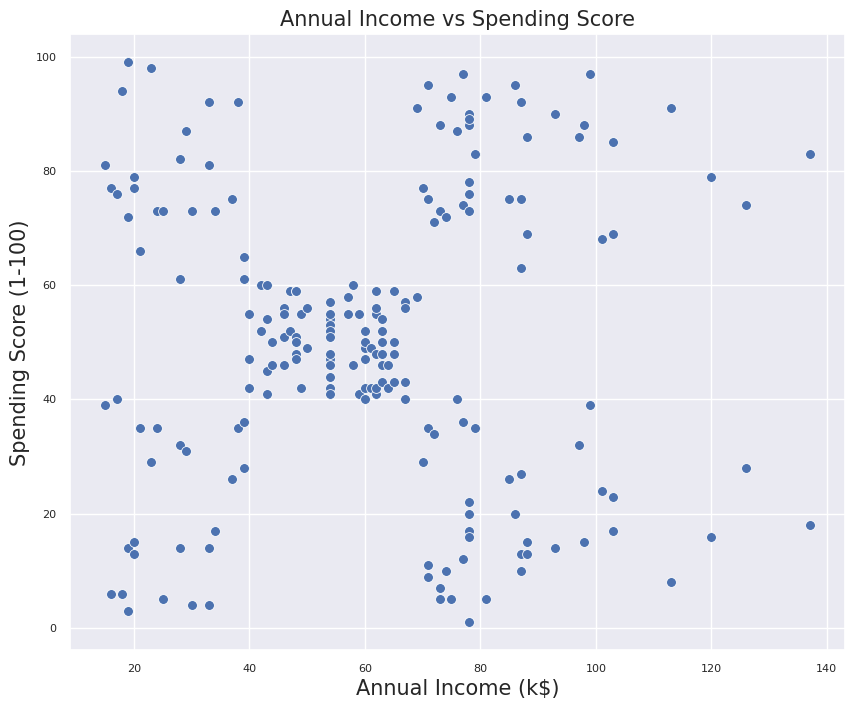

In [18]:
# df.columns
sns.scatterplot(data=df, x="Annual Income (k$)", y="Spending Score (1-100)",s=50)
plt.title("Annual Income vs Spending Score")
plt.show()

**Inference: We can clearly see clusters in this plot.**

**4. Data Preprocessing**

In [19]:
# feature selection
columns_to_select = ["Annual Income (k$)", "Spending Score (1-100)"]

X = df[columns_to_select]

In [20]:
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [21]:

# scale the features (K-means is distance-based)
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [22]:
X_scaled[:5]

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992]])

**5. Elbow Method - WCSS**

(Find best k value)

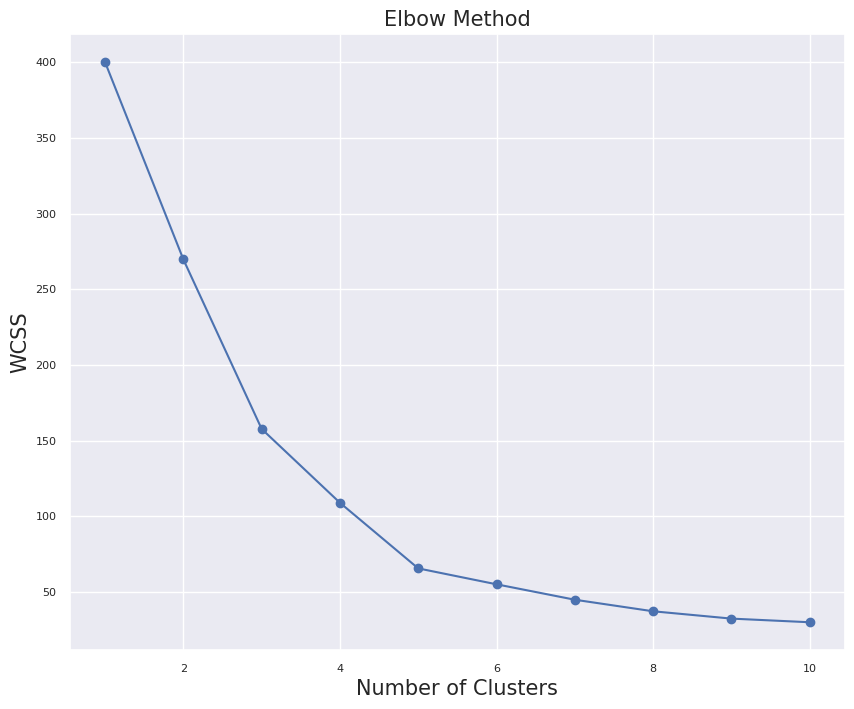

In [23]:
wcss = []
k_range = range(1,11)

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE,n_init=10)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)

plt.plot(k_range, wcss,marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

**Inference: From k = 5, within cluster sum of squares decreases marginally,hence, it is best for KMeans Clustering.**
**So, k=5 is elbow point.**

**6. K-Means Clustering**

In [24]:
K_FINAL = 5

In [25]:
kmeans_final = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE,n_init=10)


In [26]:
kmeans_final.fit(X_scaled)

KMeans(n_clusters=5, n_init=10, random_state=42)

In [27]:
clusters = kmeans_final.predict(X_scaled)

In [28]:
clusters

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [29]:
# copy of original df
df_clusters = df.copy(deep=True)

In [30]:
df_clusters

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [33]:
# Add cluster group predictions to the new dataframe df_clusters
df_clusters["clusters"] = clusters

0      4
1      2
2      4
3      2
4      4
      ..
195    1
196    3
197    1
198    3
199    1
Name: clusters, Length: 200, dtype: int32


In [32]:
df_clusters.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100),clusters
0,Male,19,15,39,4
1,Male,21,15,81,2
2,Female,20,16,6,4
3,Female,23,16,77,2
4,Female,31,17,40,4


**7. Evaluation**

In [34]:
k_means_score = silhouette_score(X_scaled, df_clusters["clusters"])
print("K Means Silhouette Score: ", round(k_means_score,2))

K Means Silhouette Score:  0.55


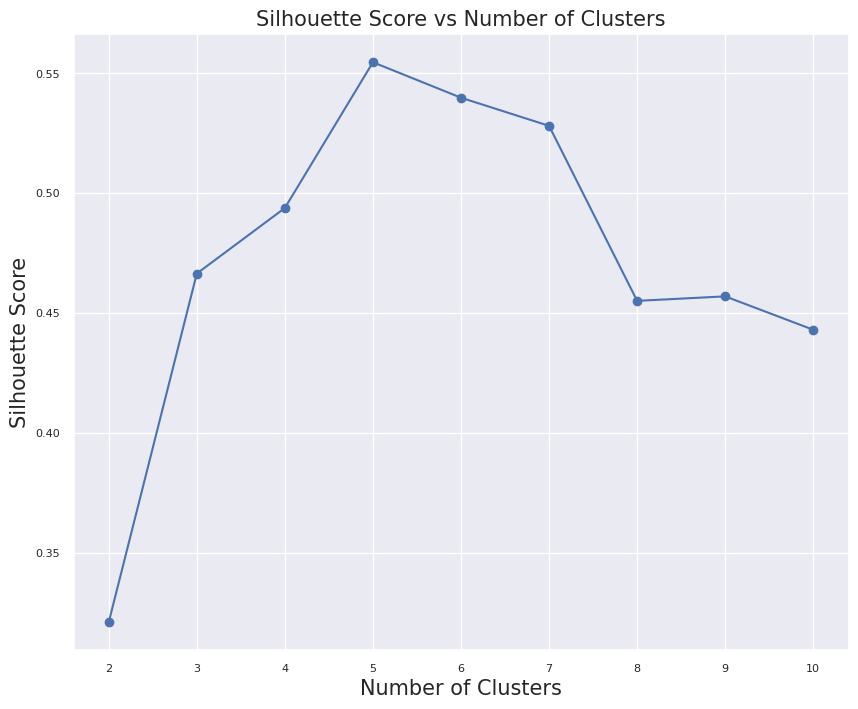

In [35]:
sil_scores = []

k_range = range(2,11)

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE,n_init=10)
  cluster_labels = kmeans.fit_predict(X_scaled)
  sil_scores.append(silhouette_score(X_scaled, cluster_labels))

plt.plot(k_range, sil_scores, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs Number of Clusters")
plt.show()

**8. Visualize Clusters**

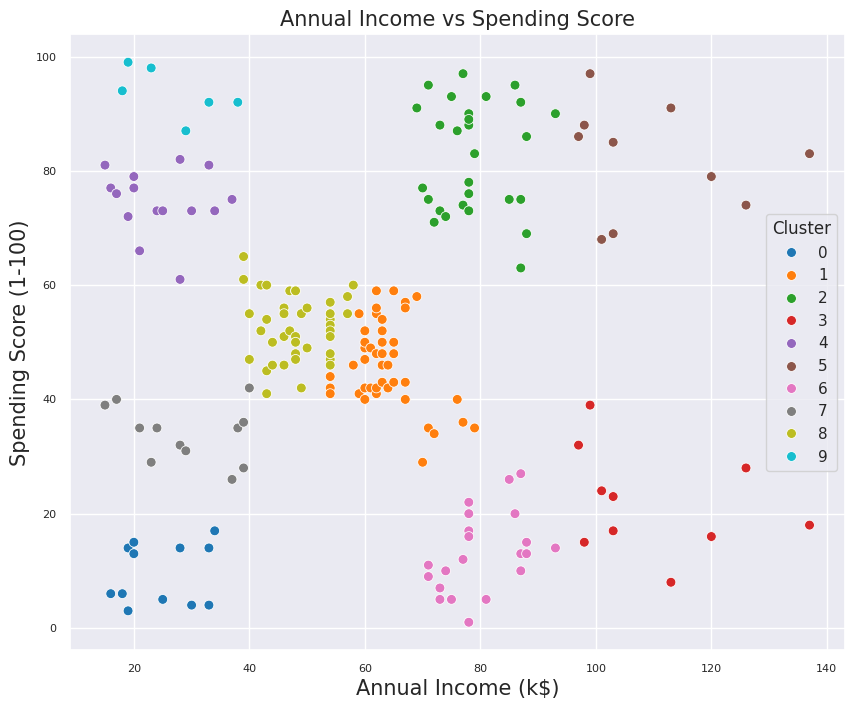

In [39]:
sns.scatterplot(data=df_clusters, x="Annual Income (k$)", y="Spending Score (1-100)",hue=cluster_labels, palette="tab10", s=50)
plt.title("Annual Income vs Spending Score")
plt.legend(title="Cluster")
plt.show()
#

**9. Cluster Interpretation (Business Profiling)**

In [43]:
df_clusters.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)',
       'clusters'],
      dtype='object')

In [51]:
profile_cols = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

cluster_sizes = df_clusters["clusters"].value_counts().sort_index()
print("Cluster Sizes:\n")
print(cluster_sizes)

cluster_profile_mean = df_clusters.groupby("clusters")[profile_cols].mean()

print("Cluster Profile (Mean):\n")
print(cluster_profile_mean)

cluster_profile_median = df_clusters.groupby("clusters")[profile_cols].median()

print("Cluster Profile (Median):\n")
print(cluster_profile_median)
#

Cluster Sizes:

clusters
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64
Cluster Profile (Mean):

            Age  Annual Income (k$)  Spending Score (1-100)
clusters                                                   
0        42.716              55.296                  49.519
1        32.692              86.538                  82.128
2        25.273              25.727                  79.364
3        41.114              88.200                  17.114
4        45.217              26.304                  20.913
Cluster Profile (Median):

            Age  Annual Income (k$)  Spending Score (1-100)
clusters                                                   
0        46.000              54.000                  50.000
1        32.000              79.000                  83.000
2        23.500              24.500                  77.000
3        42.000              85.000                  16.000
4        46.000              25.000                  17.000


In [52]:
df_clusters

,Gender,Age,Annual Income (k$),Spending Score (1-100),clusters
0,Male,19,15,39,4
1,Male,21,15,81,2
2,Female,20,16,6,4
3,Female,23,16,77,2
4,Female,31,17,40,4
...,...,...,...,...,...
195,Female,35,120,79,1
196,Female,45,126,28,3
197,Male,32,126,74,1
198,Male,32,137,18,3


**10. Segment Assignment Function (for new customers)**

In [57]:
def assign_customer_segment(annual_income, spending_score, scaler, model):
  new_point = pd.DataFrame([[annual_income, spending_score]], columns=["Annual Income (k$)", "Spending Score (1-100)"])
  new_point_scaled = scaler.transform(new_point)
  cluster = model.predict(new_point_scaled)
  return cluster[0]

In [58]:
new_cluster = assign_customer_segment(
    annual_income=60,
    spending_score=65,
    scaler=scaler,
    model=kmeans
)

print("\n New customer assigned to cluster:", new_cluster)


 New customer assigned to cluster: 8
